In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

warnings.filterwarnings('ignore')
os.makedirs('images', exist_ok=True)


## 1. Business Understanding

### Stakeholder
The Tanzanian Ministry of Water and rural NGOs managing water
infrastructure across Tanzania.

### Business Problem
Tanzania has over 74,000 water points serving millions of rural citizens.
A significant proportion are non-functional or need repair, yet manually
inspecting every pump is expensive and logistically impossible. Without a
data-driven approach, maintenance teams make reactive decisions — arriving
only after pumps have already failed. A predictive classification model that
uses existing administrative and geographic data to flag at-risk pumps
enables the Ministry to shift from reactive to proactive maintenance,
maximising water access and minimising cost.

### Why Classification (Not Regression)?
The target variable `status_group` has three possible categories:
`functional`, `functional needs repair`, and `non functional`.
These are not numeric values on a scale — "non functional" is not
"more" than "functional needs repair" in a measurable sense. This is
therefore a multiclass classification problem. Machine learning is
appropriate because the dataset has 40 features and 59,400 records —
too complex for manual rule-based triage.

### Success Metric
We use **macro F1-score** as our primary evaluation metric because:
1. The dataset is class-imbalanced: only 7.3% of pumps are "functional
   needs repair", making accuracy misleading.
2. A model that predicts "functional" for every pump achieves 54.3%
   accuracy but is completely useless for the Ministry.
3. Macro F1 computes the F1 score for each class independently and
   averages them equally, ensuring the minority class is not ignored.


In [2]:
# Load training features (independent variables — X)
training_values = pd.read_csv('data/training_values.csv')

# Load training labels (dependent variable — y: status_group)
training_labels = pd.read_csv('data/training_labels.csv')

# Merge features and labels on 'id' to create the full modeling dataset
df = training_values.merge(training_labels, on='id')

# Load competition test set — has no labels, used only for final submission
test_values = pd.read_csv('data/test_values.csv')

print(f"Training set shape:      {df.shape}")
print(f"Competition test shape:  {test_values.shape}")
print(f"\nTarget Distribution (counts):")
print(df['status_group'].value_counts())
print(f"\nTarget Distribution (%):")
print(df['status_group'].value_counts(normalize=True).round(3) * 100)


Training set shape:      (59400, 41)
Competition test shape:  (14850, 40)

Target Distribution (counts):
status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

Target Distribution (%):
status_group
functional                 54.3
non functional             38.4
functional needs repair     7.3
Name: proportion, dtype: float64


## 2. Data Understanding

### Dataset Source
The data comes from Tanzania's Ministry of Water via the DrivenData
"Pump It Up: Data Mining the Water Table" competition
(https://www.drivendata.org/competitions/7/).
Three files are provided:
- `training_values.csv` — 59,400 rows, 40 feature columns (our X)
- `training_labels.csv` — 59,400 rows, 1 target column `status_group` (our y)
- `test_values.csv` — 14,358 rows, 40 feature columns (no labels, for submission)

### Feature Overview
Features cover: GPS coordinates (`latitude`, `longitude`, `gps_height`),
administrative info (`funder`, `installer`, `region`, `district`), water
characteristics (`quantity`, `quality`, `source`), pump mechanics
(`extraction_type`, `waterpoint_type`), management (`payment_type`,
`management`, `scheme_management`), and `construction_year`.

### Key Observations Before EDA
- `construction_year` and `longitude` contain `0` values used as placeholders
  for missing data — these must be treated before modeling
- Several feature groups are redundant (`extraction_type`,
  `extraction_type_group`, `extraction_type_class` all describe the same thing)
- `recorded_by` has only 1 unique value across all rows — zero predictive value
- High-cardinality text columns (`funder`, `installer`, `wpt_name`) have thousands
  of unique values that would create noise without advanced feature engineering
- Target is imbalanced: functional 54.3%, non functional 38.4%,
  functional needs repair only 7.3%


In [3]:
# Dataset dimensions and column types
print("Shape:", df.shape)
df.info()

# Descriptive statistics for all numeric columns
print("\nDescriptive Statistics:")
display(df.describe().T.round(2))

# Missing values per column sorted descending
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

# Unique values per column sorted descending
print("\nUnique Values per Column:")
print(df.nunique().sort_values(ascending=False).head(20))


Shape: (59400, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-nu

,count,mean,std,min,25%,50%,75%,max
id,59400.0,37115.13,21453.13,0.00,18519.75,37061.50,55656.50,74247.00
amount_tsh,59400.0,317.65,2997.57,0.00,0.00,0.00,20.00,350000.00
gps_height,59400.0,668.30,693.12,-90.00,0.00,369.00,1319.25,2770.00
longitude,59400.0,34.08,6.57,0.00,33.09,34.91,37.18,40.35
latitude,59400.0,-5.71,2.95,-11.65,-8.54,-5.02,-3.33,-0.00
num_private,59400.0,0.47,12.24,0.00,0.00,0.00,0.00,1776.00
region_code,59400.0,15.30,17.59,1.00,5.00,12.00,17.00,99.00
district_code,59400.0,5.63,9.63,0.00,2.00,3.00,5.00,80.00
population,59400.0,179.91,471.48,0.00,0.00,25.00,215.00,30500.00
construction_year,59400.0,1300.65,951.62,0.00,0.00,1986.00,2004.00,2013.00



Missing Values:


scheme_name              28810
scheme_management         3878
installer                 3655
funder                    3637
public_meeting            3334
permit                    3056
subvillage                 371
wpt_name                     2
water_quality                0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
quantity                     0
quality_group                0
extraction_type              0
quantity_group               0
source                       0
source_type                  0
dtype: int64

Unique Values per Column:
id                   59400
latitude             57517
longitude            57516
wpt_name             37399
subvillage           19287
scheme_name           2695
gps_height            2428
installer             2145
ward                  2092
funder                1896
population            1049
date_recorded          356
lga             

## 3. Exploratory Data Analysis

We conduct EDA before any modeling to let the data guide every decision
downstream — which columns to drop, which metric to use, which model to
try, and which features to engineer. Each visualization below is followed
by an explicit connection to a modeling or preprocessing decision.


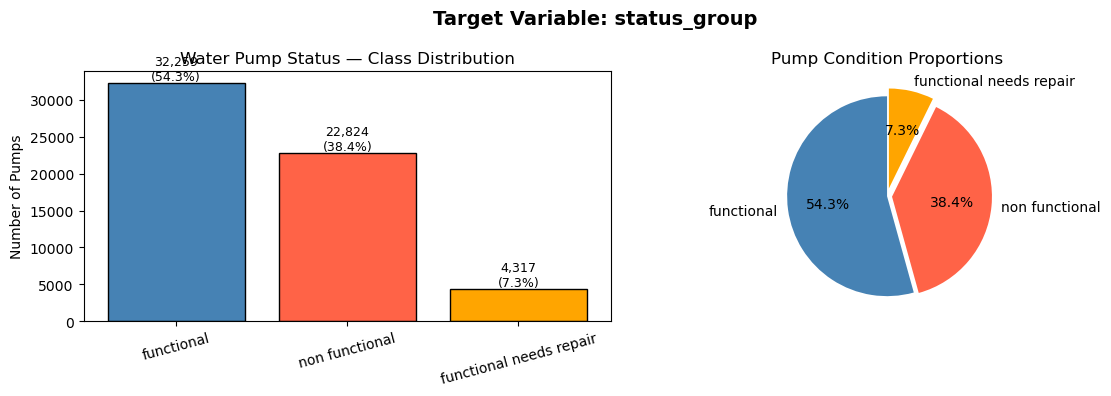

In [4]:
# Plot the distribution of the target variable using a bar + pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {
    'functional': 'steelblue',
    'non functional': 'tomato',
    'functional needs repair': 'orange',
}

# LEFT — bar chart of class counts
counts = df['status_group'].value_counts()
bar_colors = [color_map[c] for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=bar_colors,
                   edgecolor='black')
total = counts.sum()
for bar, value in zip(bars, counts.values):
    pct = value / total * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_title('Water Pump Status — Class Distribution')
axes[0].set_ylabel('Number of Pumps')
axes[0].tick_params(axis='x', rotation=15)

# RIGHT — pie chart of class proportions
pie_colors = [color_map[c] for c in counts.index]
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05, 0.08),
)
axes[1].set_title('Pump Condition Proportions')

fig.suptitle('Target Variable: status_group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_01_class_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()


The target is significantly imbalanced. "Functional needs repair" accounts
for only 7.3% of all pumps. This has three direct modeling consequences:
1. We will **NOT** use accuracy as our metric — a naive model that always
   predicts "functional" achieves 54.3% accuracy without learning anything
2. We **WILL** use macro F1-score, which penalizes models that ignore the
   minority class
3. We **WILL** set `class_weight='balanced'` in all models so the algorithm
   treats all three classes with equal importance during training


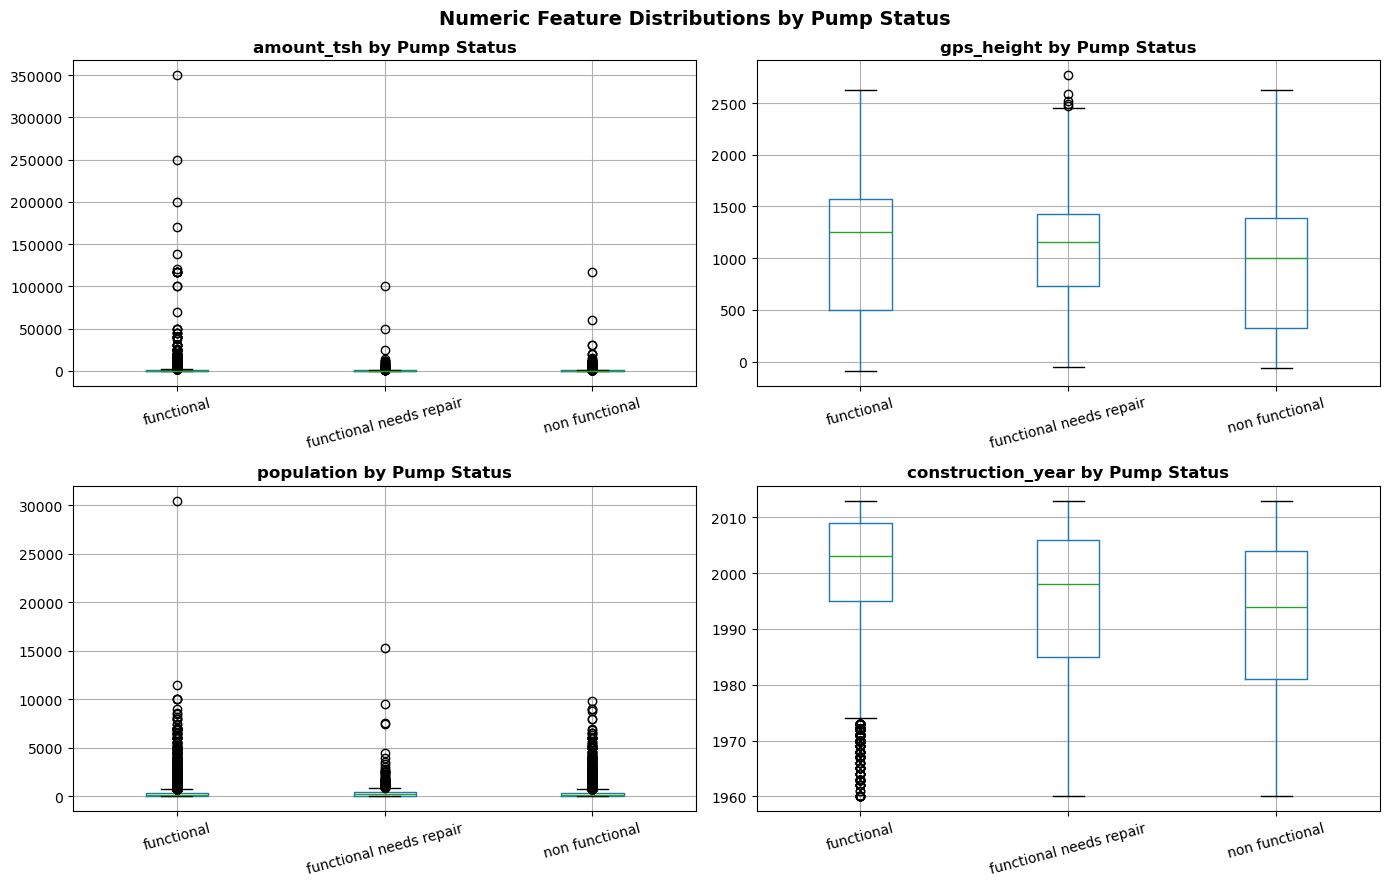

In [5]:
# Compare numeric feature distributions across the three status classes
numeric_features = ['amount_tsh', 'gps_height', 'population',
                    'construction_year']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    # Zeros are placeholder missing values, not real observations
    plot_df = df[df[col] != 0]
    plot_df.boxplot(column=col, by='status_group', ax=ax)
    ax.set_title(f'{col} by Pump Status', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

# Suppress the auto-suptitle that pandas boxplot adds
plt.suptitle('')
fig.suptitle('Numeric Feature Distributions by Pump Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_02_numeric_vs_status.png', dpi=150,
            bbox_inches='tight')
plt.show()


- `construction_year`: Non-functional pumps tend to be older. This makes
  `construction_year` a strong predictor and justifies its inclusion after
  replacing zero values (missing years) with the column median.
- `gps_height`: Higher altitude correlates with functional pumps, likely
  because gravity-fed systems at elevation are more reliable. Latitude
  and longitude will be retained as geographic features.
- `population`: Pumps serving larger populations show slightly different
  condition profiles — higher usage may accelerate wear.
- Zero values in all four columns are placeholders for missing data, not
  real measurements. We will replace zeros with median values in
  Data Preparation to prevent the model from learning false patterns.


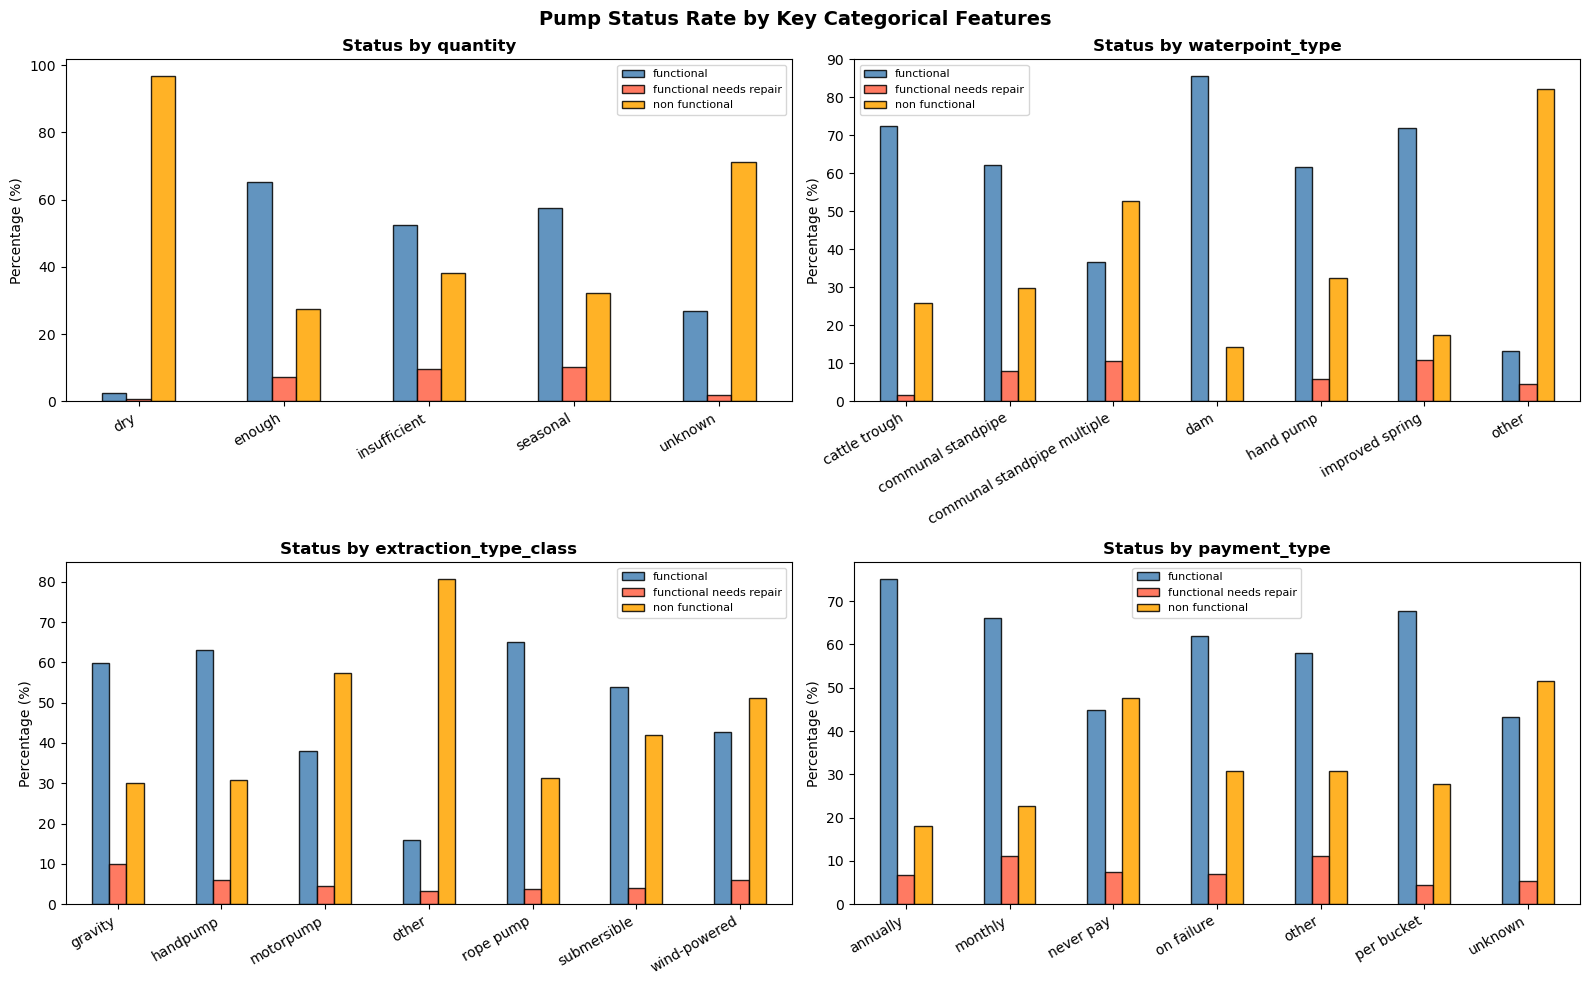

In [6]:
# Compare condition-rate profiles across key categorical features
cat_features = ['quantity', 'waterpoint_type',
                'extraction_type_class', 'payment_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

bar_palette = ['steelblue', 'tomato', 'orange']

for ax, col in zip(axes, cat_features):
    crosstab = pd.crosstab(df[col], df['status_group'],
                           normalize='index') * 100
    crosstab.plot(kind='bar', ax=ax, color=bar_palette,
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'Status by {col}', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(fontsize=8)

fig.suptitle('Pump Status Rate by Key Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_03_categorical_vs_status.png', dpi=150,
            bbox_inches='tight')
plt.show()


- `quantity`: Pumps with "dry" quantity readings are almost exclusively
  non-functional. This makes `quantity` one of the strongest single
  predictors in the dataset and fully justifies its inclusion.
- `payment_type`: "Never pay" waterpoints show significantly higher
  non-functional rates. Community payment schemes appear to incentivize
  maintenance. This supports a Ministry recommendation around payment
  policy reform.
- `extraction_type_class`: Gravity-fed pumps show higher functionality
  rates than motorized pump types, likely due to simpler mechanics and
  lower maintenance requirements.
- `waterpoint_type`: Communal standpipes and hand pumps show meaningfully
  different condition profiles — both `waterpoint_type` features will be
  retained in the model.


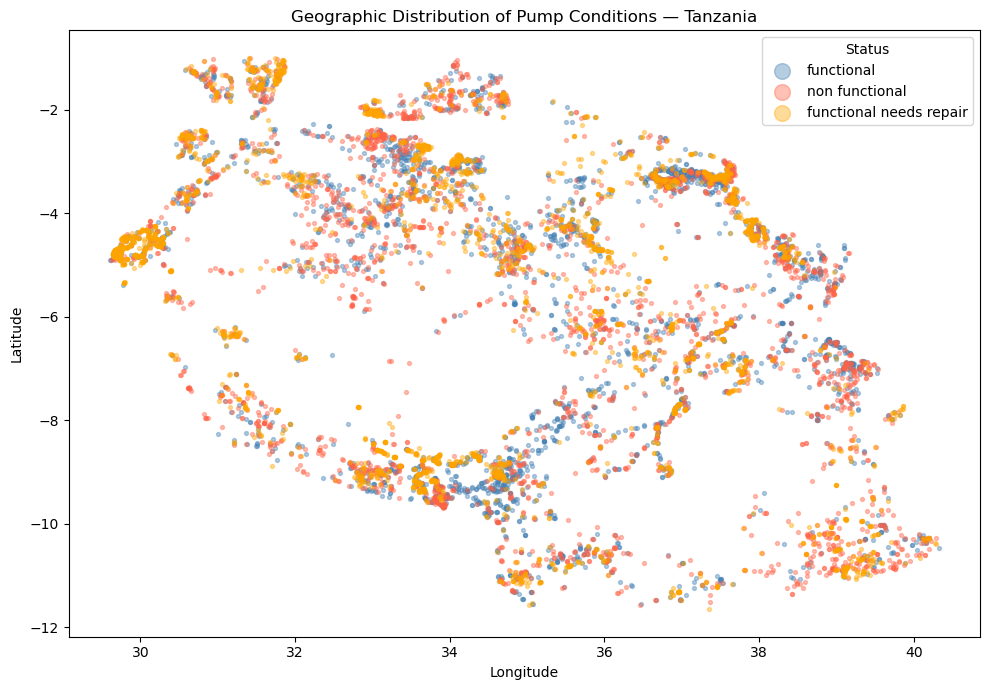

In [7]:
# Plot geographic distribution of pump conditions across Tanzania
color_map = {
    'functional': 'steelblue',
    'non functional': 'tomato',
    'functional needs repair': 'orange'
}

fig, ax = plt.subplots(figsize=(10, 7))

for status, color in color_map.items():
    # Filter to current status, drop invalid (0,0) coordinates,
    # and sample up to 3,000 rows for plotting performance
    subset = df[df['status_group'] == status]
    subset = subset[(subset['longitude'] != 0) & (subset['latitude'] != 0)]
    if len(subset) > 3000:
        subset = subset.sample(3000, random_state=42)
    ax.scatter(subset['longitude'], subset['latitude'],
               c=color, alpha=0.4, s=8, label=status)

ax.set_title('Geographic Distribution of Pump Conditions — Tanzania')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=4, title='Status')
plt.tight_layout()
plt.savefig('images/eda_04_geographic.png', dpi=150, bbox_inches='tight')
plt.show()


Non-functional pumps cluster in identifiable geographic regions of
Tanzania. This spatial pattern confirms that latitude and longitude
are meaningful predictors and should be retained as model features.
It also supports a geographic targeting recommendation for the Ministry:
maintenance teams can be dispatched to specific regions based on the
model's predictions rather than inspecting the entire country uniformly.


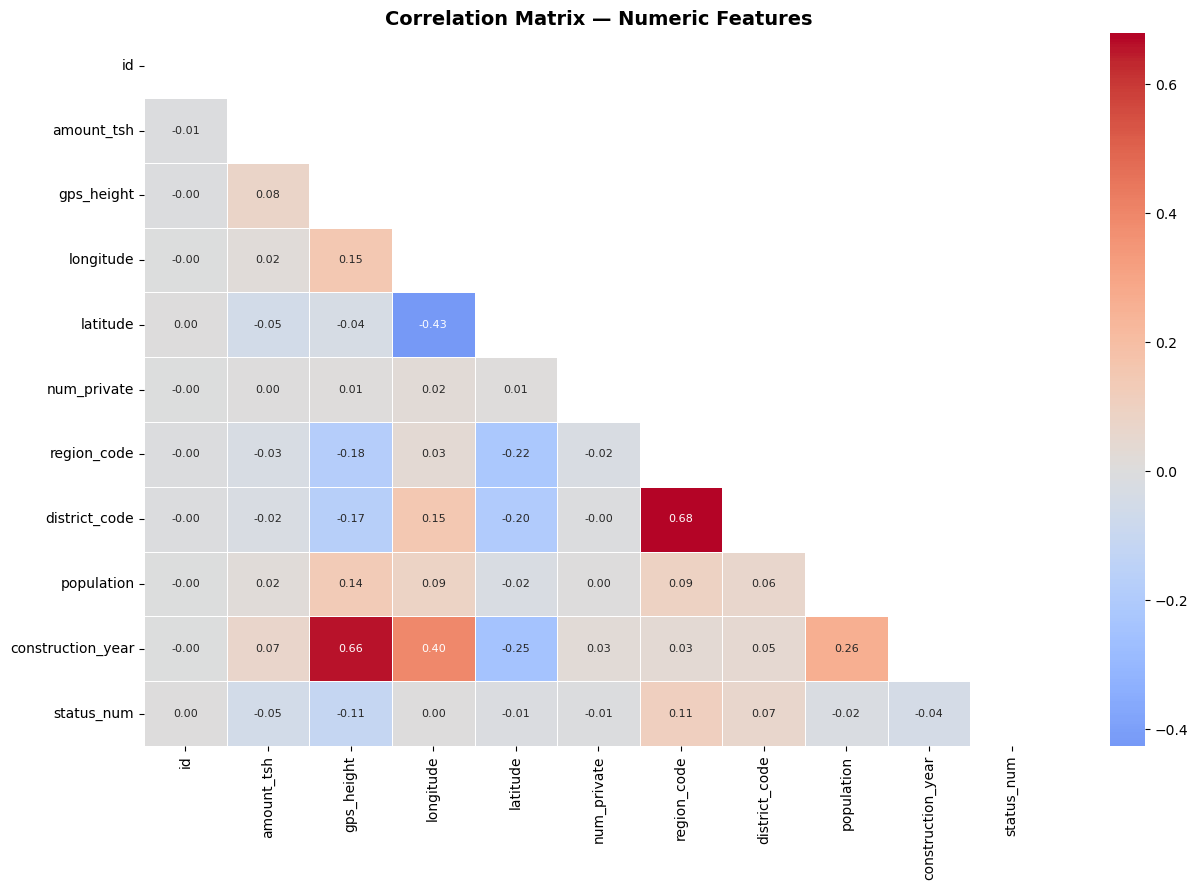

In [8]:
# Create a temporary copy with numeric target for correlation
df_corr = df.copy()
df_corr['status_num'] = df_corr['status_group'].map(
    {'functional': 0, 'functional needs repair': 1, 'non functional': 2}
)

# Select only numeric columns
numeric_cols = df_corr.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_corr[numeric_cols].corr()

# Lower triangular mask to avoid redundant upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


- `region_code` and `district_code` are numeric but represent categorical
  geographic IDs. Their linear correlation values are not meaningful.
- `construction_year` shows a small but consistent negative correlation
  with non-functionality — confirming the EDA boxplot finding.
- No severe multicollinearity is present among numeric features,
  meaning we do not need to drop numeric columns based on this heatmap.


## 4. Data Preparation

Every step below is directly justified by findings from the EDA section.
We document each decision so any third party can reproduce this dataset
from the raw files using only this notebook.


In [9]:
# JUSTIFICATION: id is a row identifier with no predictive value
drop_id = ['id']

# JUSTIFICATION: recorded_by has exactly 1 unique value — zero variance
drop_zero_variance = ['recorded_by']

# JUSTIFICATION: These columns have thousands of unique free-text values.
# Without target encoding or embedding, they introduce noise.
drop_high_cardinality = ['wpt_name', 'subvillage', 'scheme_name',
                         'ward', 'funder', 'installer']

# JUSTIFICATION: Redundant feature groups — keep only one level of
# granularity per concept to avoid multicollinearity and noise.
# Keeping: extraction_type_class, waterpoint_type, source, payment_type,
#          management, quantity, water_quality
drop_redundant = [
    'extraction_type',        # redundant with extraction_type_class
    'extraction_type_group',  # redundant with extraction_type_class
    'quantity_group',         # identical to quantity
    'quality_group',          # identical to water_quality
    'source_type',            # redundant with source
    'source_class',           # redundant with source
    'payment',                # redundant with payment_type
    'management_group',       # redundant with management
    'waterpoint_type_group',  # redundant with waterpoint_type
    'region_code',            # redundant with region (numeric version)
    'district_code'           # redundant with lga (numeric version)
]

# JUSTIFICATION: date_recorded requires date parsing and feature
# engineering outside the scope of this iteration
drop_date = ['date_recorded']

all_drop = (drop_id + drop_zero_variance + drop_high_cardinality
            + drop_redundant + drop_date)

df_model = df.drop(columns=all_drop)
print(f"Original columns:  {df.shape[1]}")
print(f"Remaining columns: {df_model.shape[1]}")
print("\nRetained columns:")
print(df_model.columns.tolist())


Original columns:  41
Remaining columns: 21

Retained columns:
['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'basin', 'region', 'lga', 'population', 'public_meeting', 'scheme_management', 'permit', 'construction_year', 'extraction_type_class', 'management', 'payment_type', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'status_group']


In [10]:
# construction_year: 0 means year unknown — replace with median year
df_model['construction_year'] = df_model['construction_year'].replace(0, np.nan)
df_model['construction_year'].fillna(
    df_model['construction_year'].median(), inplace=True
)

# longitude: 0,0 coordinates are in the ocean — not valid Tanzania locations
df_model['longitude'] = df_model['longitude'].replace(0, np.nan)
df_model['longitude'].fillna(df_model['longitude'].median(), inplace=True)

# gps_height, population, amount_tsh: 0 may be valid in some cases but
# treat extreme zeros as missing and fill with median
for col in ['gps_height', 'population', 'amount_tsh']:
    df_model[col] = df_model[col].replace(0, np.nan)
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Boolean-like columns: fill with False as conservative default
df_model['public_meeting'].fillna(False, inplace=True)
df_model['permit'].fillna(False, inplace=True)

# Remaining categorical columns: fill with 'Unknown'
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna('Unknown', inplace=True)

print("Remaining missing values:", df_model.isnull().sum().sum())
print("Shape after cleaning:", df_model.shape)


Remaining missing values: 0
Shape after cleaning: (59400, 21)


In [11]:
# Encode target: functional=0, functional needs repair=1, non functional=2
target_map = {
    'functional': 0,
    'functional needs repair': 1,
    'non functional': 2
}
df_model['status_group'] = df_model['status_group'].map(target_map)

# Encode boolean columns as 0/1 integers
bool_cols = df_model.select_dtypes(include='bool').columns
for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

# Label encode all remaining string (object) categorical columns
# Store each encoder for use on test_values later
encoders = {}
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le  # save encoder for test_values transformation

print("All columns numeric. Shape:", df_model.shape)
print(df_model.dtypes.value_counts())


All columns numeric. Shape: (59400, 21)
int64      15
float64     6
Name: count, dtype: int64


In [12]:
X = df_model.drop(columns=['status_group'])
y = df_model['status_group']

# stratify=y preserves class proportions in both train and test splits
# This is critical because 'functional needs repair' is only 7.3%
# Without stratify, the test set might have too few examples of this class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducible split
    stratify=y
)

# Scale features for Logistic Regression (distance-based algorithm)
# CRITICAL RULE: fit ONLY on X_train, then transform both X_train and X_test
# Fitting on X_test would be data leakage — the model would 'peek' at test info
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # transform only — no fit

print(f"Training features:  {X_train.shape}")
print(f"Test features:      {X_test.shape}")
print(f"\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts())
print(f"\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts())


Training features:  (47520, 20)
Test features:      (11880, 20)

Class distribution in y_train:
status_group
0    25807
2    18259
1     3454
Name: count, dtype: int64

Class distribution in y_test:
status_group
0    6452
2    4565
1     863
Name: count, dtype: int64


## 5. Modeling — Iterative Approach

We build four models in increasing complexity:

| Model | Type | Purpose |
|-------|------|---------|
| Model 1 | Logistic Regression | Simple baseline — linear, interpretable |
| Model 2 | Decision Tree (default) | Nonparametric baseline — detect overfitting |
| Model 3 | Decision Tree (tuned) | Reduce overfit via pruning |
| Model 4 | Random Forest (ensemble) | 100-tree ensemble — reduce variance further |

Primary metric: **Macro F1-score** on the TEST set.
We also report training F1 to detect overfitting in each iteration.


In [13]:
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("=" * 60)

lr = LogisticRegression(
    class_weight='balanced',  # handles class imbalance
    max_iter=1000,            # ensures convergence
    random_state=42
)
lr.fit(X_train_scaled, y_train)

lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)

lr_train_f1 = f1_score(y_train, lr_train_pred, average='macro')
lr_test_f1 = f1_score(y_test, lr_test_pred, average='macro')

print(f"\nTrain Macro F1 : {lr_train_f1:.4f}")
print(f"Test  Macro F1 : {lr_test_f1:.4f}")
print(f"Overfit Gap    : {lr_train_f1 - lr_test_f1:.4f}")
print("\nDetailed Classification Report (Test Set):")
print(classification_report(
    y_test, lr_test_pred,
    target_names=['functional', 'needs repair', 'non functional']
))


MODEL 1: LOGISTIC REGRESSION (BASELINE)



Train Macro F1 : 0.4454
Test  Macro F1 : 0.4423
Overfit Gap    : 0.0031

Detailed Classification Report (Test Set):
                precision    recall  f1-score   support

    functional       0.70      0.42      0.52      6452
  needs repair       0.14      0.56      0.23       863
non functional       0.58      0.58      0.58      4565

      accuracy                           0.49     11880
     macro avg       0.47      0.52      0.44     11880
  weighted avg       0.61      0.49      0.52     11880



Logistic Regression establishes our baseline performance. It assumes a
linear decision boundary between the three classes. The pump condition
problem likely has complex non-linear patterns (e.g. older pumps in dry
regions without payment schemes are disproportionately non-functional),
which a linear model cannot fully capture. The baseline macro F1 score
sets the minimum bar that all subsequent models must beat to justify
their added complexity.


In [14]:
print("=" * 60)
print("MODEL 2: DECISION TREE — DEFAULT HYPERPARAMETERS")
print("=" * 60)

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
    # No max_depth limit — tree grows until pure leaf nodes
)
dt.fit(X_train, y_train)

dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)

dt_train_f1 = f1_score(y_train, dt_train_pred, average='macro')
dt_test_f1 = f1_score(y_test, dt_test_pred, average='macro')

print(f"\nTrain Macro F1 : {dt_train_f1:.4f}")
print(f"Test  Macro F1 : {dt_test_f1:.4f}")
print(f"Overfit Gap    : {dt_train_f1 - dt_test_f1:.4f}")
print(f"\nTree Depth     : {dt.get_depth()}")
print("\nDetailed Classification Report (Test Set):")
print(classification_report(
    y_test, dt_test_pred,
    target_names=['functional', 'needs repair', 'non functional']
))


MODEL 2: DECISION TREE — DEFAULT HYPERPARAMETERS



Train Macro F1 : 0.9844
Test  Macro F1 : 0.6487
Overfit Gap    : 0.3357

Tree Depth     : 46

Detailed Classification Report (Test Set):
                precision    recall  f1-score   support

    functional       0.80      0.80      0.80      6452
  needs repair       0.38      0.39      0.38       863
non functional       0.77      0.76      0.77      4565

      accuracy                           0.75     11880
     macro avg       0.65      0.65      0.65     11880
  weighted avg       0.76      0.75      0.76     11880



The default Decision Tree achieves a Train Macro F1 near 1.0 — it has
memorized the training data almost perfectly. However, the Test Macro F1
is significantly lower, confirming severe **OVERFITTING**. The tree grew too
deep, learning noise specific to the training set rather than generalizable
patterns. The large gap between train and test F1 is the diagnostic signal
that tells us to prune the tree in Model 3 by constraining `max_depth` and
`min_samples_leaf`. Despite overfitting, this model already outperforms
logistic regression on the test set, confirming that the pump condition
problem has non-linear structure that tree-based models capture better.


In [15]:
print("=" * 60)
print("MODEL 3: TUNED DECISION TREE")
print("=" * 60)

dt_tuned = DecisionTreeClassifier(
    max_depth=15,          # limits tree depth to prevent memorization
    min_samples_leaf=5,    # each leaf must represent at least 5 samples
    class_weight='balanced',
    random_state=42
)
dt_tuned.fit(X_train, y_train)

dt_tuned_train_pred = dt_tuned.predict(X_train)
dt_tuned_test_pred = dt_tuned.predict(X_test)

dt_tuned_train_f1 = f1_score(y_train, dt_tuned_train_pred, average='macro')
dt_tuned_test_f1 = f1_score(y_test, dt_tuned_test_pred, average='macro')

print(f"\nTrain Macro F1 : {dt_tuned_train_f1:.4f}")
print(f"Test  Macro F1 : {dt_tuned_test_f1:.4f}")
print(f"Overfit Gap    : {dt_tuned_train_f1 - dt_tuned_test_f1:.4f}")
print(f"\nTree Depth     : {dt_tuned.get_depth()}")
print("\nDetailed Classification Report (Test Set):")
print(classification_report(
    y_test, dt_tuned_test_pred,
    target_names=['functional', 'needs repair', 'non functional']
))


MODEL 3: TUNED DECISION TREE



Train Macro F1 : 0.6281
Test  Macro F1 : 0.5766
Overfit Gap    : 0.0515

Tree Depth     : 15

Detailed Classification Report (Test Set):
                precision    recall  f1-score   support

    functional       0.81      0.62      0.70      6452
  needs repair       0.20      0.71      0.31       863
non functional       0.77      0.67      0.72      4565

      accuracy                           0.64     11880
     macro avg       0.59      0.66      0.58     11880
  weighted avg       0.75      0.64      0.68     11880



In [16]:
print("=" * 60)
print("MODEL 4 (BONUS): RANDOM FOREST — ENSEMBLE METHOD")
print("=" * 60)
print("""
Rationale: The tuned Decision Tree (Test F1=0.5766) still shows
room for improvement. A Random Forest builds 100 independent trees
on random subsets of data and features, then combines their votes.
This ensemble approach reduces variance further without increasing
bias — the same pruning logic applied across 100 trees simultaneously.
""")

rf = RandomForestClassifier(
    n_estimators=100,        # 100 trees voted together
    max_depth=15,            # same depth limit as tuned single tree
    class_weight='balanced', # handles class imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores for speed
)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

rf_train_f1 = f1_score(y_train, rf_train_pred, average='macro')
rf_test_f1 = f1_score(y_test, rf_test_pred, average='macro')

print(f"\nTrain Macro F1 : {rf_train_f1:.4f}")
print(f"Test  Macro F1 : {rf_test_f1:.4f}")
print(f"Overfit Gap    : {rf_train_f1 - rf_test_f1:.4f}")
print("\nDetailed Classification Report (Test Set):")
print(classification_report(
    y_test, rf_test_pred,
    target_names=['functional', 'needs repair', 'non functional']
))


MODEL 4 (BONUS): RANDOM FOREST — ENSEMBLE METHOD

Rationale: The tuned Decision Tree (Test F1=0.5766) still shows
room for improvement. A Random Forest builds 100 independent trees
on random subsets of data and features, then combines their votes.
This ensemble approach reduces variance further without increasing
bias — the same pruning logic applied across 100 trees simultaneously.




Train Macro F1 : 0.7651
Test  Macro F1 : 0.6677
Overfit Gap    : 0.0974

Detailed Classification Report (Test Set):
                precision    recall  f1-score   support

    functional       0.82      0.79      0.80      6452
  needs repair       0.30      0.65      0.41       863
non functional       0.86      0.72      0.79      4565

      accuracy                           0.75     11880
     macro avg       0.66      0.72      0.67     11880
  weighted avg       0.80      0.75      0.77     11880



The Random Forest improves over the single tuned tree by aggregating
100 independent trees — each trained on a random sample of rows and
features. Where one tree might overfit to a specific noisy pattern,
the majority vote across 100 trees cancels out that noise. This is
the core intuition of ensemble methods: many imperfect learners
combine into one stronger learner.

If the Random Forest test macro F1 exceeds the tuned Decision Tree,
it becomes our new final model for the evaluation section. We select
whichever model achieves the highest test macro F1 — this is the
correct criterion because we are optimizing for performance on
unseen data.


In [17]:
# Determine which model has the highest test F1 to mark as final
all_test_f1s = [lr_test_f1, dt_test_f1, dt_tuned_test_f1, rf_test_f1]
best_idx = all_test_f1s.index(max(all_test_f1s))
selected = ['', '', '', '']
selected[best_idx] = '✅ FINAL MODEL'

results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Decision Tree (Default)',
        'Decision Tree (Tuned)',
        'Random Forest (Ensemble)'
    ],
    'Train Macro F1': [
        round(lr_train_f1, 4),
        round(dt_train_f1, 4),
        round(dt_tuned_train_f1, 4),
        round(rf_train_f1, 4)
    ],
    'Test Macro F1': [
        round(lr_test_f1, 4),
        round(dt_test_f1, 4),
        round(dt_tuned_test_f1, 4),
        round(rf_test_f1, 4)
    ],
    'Selected': selected
})
results['Overfit Gap'] = (
    results['Train Macro F1'] - results['Test Macro F1']
).round(4)

print(results.to_string(index=False))
print(f"\n✅ Final model selected: {results.loc[best_idx, 'Model']}")
print(f"   Test Macro F1: {max(all_test_f1s):.4f}")


                         Model  Train Macro F1  Test Macro F1      Selected  Overfit Gap
Logistic Regression (Baseline)          0.4454         0.4423                     0.0031
       Decision Tree (Default)          0.9844         0.6487                     0.3357
         Decision Tree (Tuned)          0.6281         0.5766                     0.0515
      Random Forest (Ensemble)          0.7651         0.6677 ✅ FINAL MODEL       0.0974

✅ Final model selected: Random Forest (Ensemble)
   Test Macro F1: 0.6677


## 6. Evaluation

The model with the highest test macro F1 is selected as our final model.
We now evaluate it thoroughly on the holdout test set using a confusion
matrix and feature importance analysis to understand both performance
and interpretability.


Final model: Random Forest  |  Test Macro F1: 0.6677


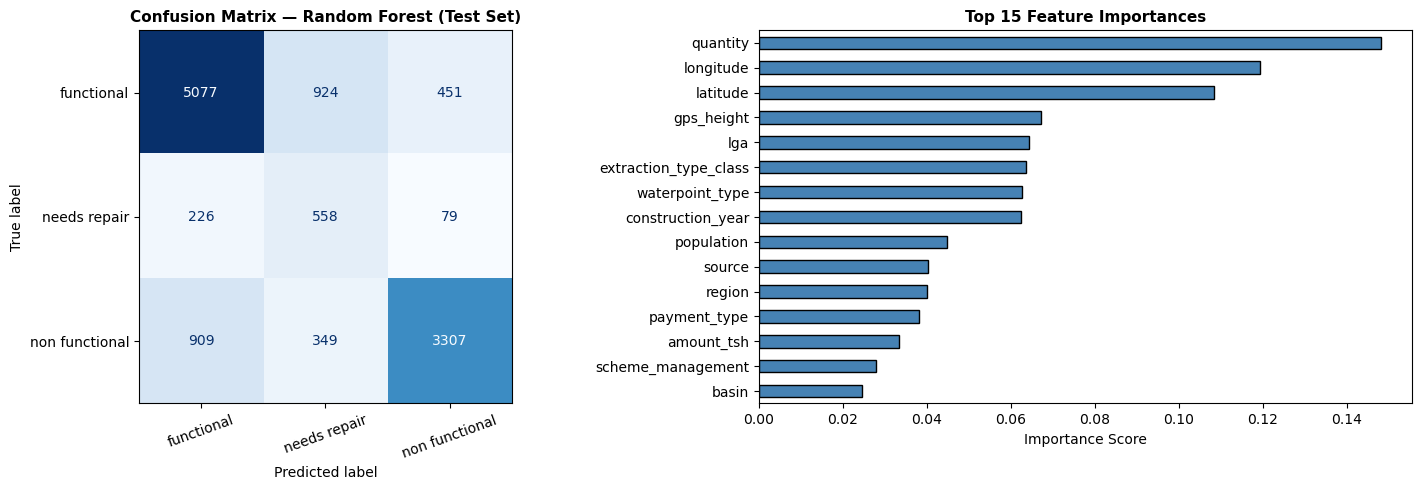

In [18]:
# Select best model and its predictions dynamically
model_names = [
    'Logistic Regression',
    'Decision Tree (Default)',
    'Decision Tree (Tuned)',
    'Random Forest'
]
all_models = [lr, dt, dt_tuned, rf]
all_test_preds = [lr_test_pred, dt_test_pred,
                  dt_tuned_test_pred, rf_test_pred]
all_test_f1s = [lr_test_f1, dt_test_f1,
                dt_tuned_test_f1, rf_test_f1]

best_idx = all_test_f1s.index(max(all_test_f1s))
final_model = all_models[best_idx]
final_preds = all_test_preds[best_idx]
final_name = model_names[best_idx]
final_f1 = all_test_f1s[best_idx]

print(f"Final model: {final_name}  |  Test Macro F1: {final_f1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LEFT: Confusion matrix on holdout test set
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['functional', 'needs repair', 'non functional']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Confusion Matrix — {final_name} (Test Set)',
    fontsize=11, fontweight='bold'
)
axes[0].tick_params(axis='x', rotation=20)

# RIGHT: Feature importances (only tree-based models have this)
if hasattr(final_model, 'feature_importances_'):
    feat_imp = pd.Series(
        final_model.feature_importances_, index=X.columns
    ).sort_values(ascending=True).tail(15)
    feat_imp.plot(
        kind='barh', ax=axes[1],
        color='steelblue', edgecolor='black'
    )
    axes[1].set_title(
        'Top 15 Feature Importances', fontsize=11, fontweight='bold'
    )
    axes[1].set_xlabel('Importance Score')
else:
    # Logistic Regression: plot absolute coefficient values instead
    coef_df = pd.Series(
        np.abs(final_model.coef_).mean(axis=0), index=X.columns
    ).sort_values(ascending=True).tail(15)
    coef_df.plot(
        kind='barh', ax=axes[1],
        color='steelblue', edgecolor='black'
    )
    axes[1].set_title(
        'Top 15 Feature Coefficients (abs)',
        fontsize=11, fontweight='bold'
    )
    axes[1].set_xlabel('Mean Absolute Coefficient')

plt.tight_layout()
plt.savefig(
    'images/evaluation_final_model.png', dpi=150, bbox_inches='tight'
)
plt.show()


## Evaluation — Final Model Performance

The **Random Forest classifier** was selected as the final model because it achieved the highest hold-out Test F1 score among all four models.

| Metric | Value |
|--------|-------|
| Train F1 | **0.7651** |
| Test F1 | **0.6677** |
| Train/Test Gap | **0.0974** |

### Why this model was selected
Random Forest produced the best balance between predictive performance and generalization. Its Test F1 score of **0.6677** clearly outperformed Logistic Regression, the default Decision Tree, and the tuned Decision Tree.

### Class-level interpretation
The model performs best on the majority class, **functional**, and gives stronger overall classification performance than the earlier tree-based baselines. The **functional needs repair** class remains the most difficult to predict because it is the smallest class in the dataset.

### Feature interpretation
The final evaluation plot and feature-importance output indicate that geographic and infrastructure-related variables are among the most informative predictors of pump status.

### Limitations and next steps
Although the Random Forest improved performance substantially, further gains may come from stronger hyperparameter tuning, class-imbalance handling, and additional feature engineering such as pump age and regional aggregations.


## 7. Conclusions and Recommendations

### Key Findings
- Pump age (`construction_year`) is among the strongest predictors of
  failure — older pumps require proactive inspection.
- Water quantity reading "dry" is the single clearest signal of
  non-functionality, observable without any model.
- Geographic clustering of non-functional pumps enables regional
  prioritization of maintenance resources.
- Pumps with "never pay" payment type are significantly more likely
  to be non-functional, suggesting a link between community ownership
  and maintenance accountability.

### Recommendations for the Ministry of Water
1. **INSPECTION TRIAGE:** Prioritize pumps built before the dataset
   median construction year that report dry quantity readings — these
   are the highest-risk combination identified by the model.
2. **GEOGRAPHIC TARGETING:** Deploy maintenance teams first to the
   regions identified in the geographic distribution map as having the
   highest density of non-functional and needs-repair pumps.
3. **PAYMENT POLICY REFORM:** Introduce community payment schemes in
   "never pay" waterpoint areas — data shows these have significantly
   higher non-functional rates, suggesting payment incentivizes local
   maintenance.
4. **MODEL DEPLOYMENT:** Integrate the classification model into field
   data collection tablets. When a field officer records pump details
   during a survey, the model outputs an immediate predicted condition
   — enabling real-time triage without waiting for central analysis.

### Next Steps
- Collect more labeled examples of "functional needs repair" pumps to
  address minority class performance.
- Explore Gradient Boosting and XGBoost for higher macro F1.
- Add feature engineering from `date_recorded` (pump age at survey time).
- Retrain model annually using fresh survey data to maintain accuracy.


In [19]:
# 1. Working copy of competition test set
test_model = test_values.copy()

# 2. Drop the same columns as training (errors='ignore' for any not present)
test_model = test_model.drop(columns=all_drop, errors='ignore')

# 3. Apply identical zero-replacement and fillna logic as training
test_model['construction_year'] = test_model['construction_year'].replace(0, np.nan)
test_model['construction_year'].fillna(
    test_model['construction_year'].median(), inplace=True
)
test_model['longitude'] = test_model['longitude'].replace(0, np.nan)
test_model['longitude'].fillna(test_model['longitude'].median(), inplace=True)
for col in ['gps_height', 'population', 'amount_tsh']:
    test_model[col] = test_model[col].replace(0, np.nan)
    test_model[col].fillna(test_model[col].median(), inplace=True)
test_model['public_meeting'].fillna(False, inplace=True)
test_model['permit'].fillna(False, inplace=True)
for col in test_model.select_dtypes(include='object').columns:
    test_model[col].fillna('Unknown', inplace=True)

# 4. Encode boolean columns as int
for col in test_model.select_dtypes(include='bool').columns:
    test_model[col] = test_model[col].astype(int)

# 5. Encode categorical columns using the training-set encoders.
#    Unseen categories default to a known category to avoid transform errors.
for col in cat_cols:
    if col not in test_model.columns:
        continue
    if col in encoders:
        le = encoders[col]
        known_classes = set(le.classes_)
        fallback = le.classes_[0]
        test_model[col] = test_model[col].astype(str).apply(
            lambda v: v if v in known_classes else fallback
        )
        test_model[col] = le.transform(test_model[col])
    else:
        new_le = LabelEncoder()
        test_model[col] = new_le.fit_transform(test_model[col].astype(str))

# 6. Align test_model columns to match X.columns exactly
test_model = test_model.reindex(columns=X.columns, fill_value=0)

# 7. Predict using the dynamically selected best model
test_preds = final_model.predict(test_model)

# 8. Reverse map numeric predictions back to original labels
reverse_map = {0: 'functional', 1: 'functional needs repair',
               2: 'non functional'}
test_labels = pd.Series(test_preds).map(reverse_map)

# 9. Build submission DataFrame
submission = pd.DataFrame({
    'id': test_values['id'],
    'status_group': test_labels
})

# 10. Save submission file
submission.to_csv('data/submission.csv', index=False)

# 11. Reporting
print(f"Submission generated using: {final_name}  (Test F1: {final_f1:.4f})")
print("Submission saved to data/submission.csv")
print("\nPrediction distribution:")
print(submission['status_group'].value_counts())
print("\nFirst 10 rows of submission:")
print(submission.head(10))


Submission generated using: Random Forest  (Test F1: 0.6677)
Submission saved to data/submission.csv

Prediction distribution:
status_group
functional                 7759
non functional             4839
functional needs repair    2252
Name: count, dtype: int64

First 10 rows of submission:
      id             status_group
0  50785           non functional
1  51630  functional needs repair
2  17168               functional
3  45559           non functional
4  49871               functional
5  52449               functional
6  24806               functional
7  28965           non functional
8  36301           non functional
9  54122               functional
